EXPERIMENT 08 - POST LAB
ANN on Titanic Dataset
Name    : R. Karthik
Roll No : 25EU02904

Dataset Shape:
(891, 12)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)


Titanic ANN Test Accuracy: 81.56%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179


Confusion Matrix:
[[96 14]
 [19 50]]


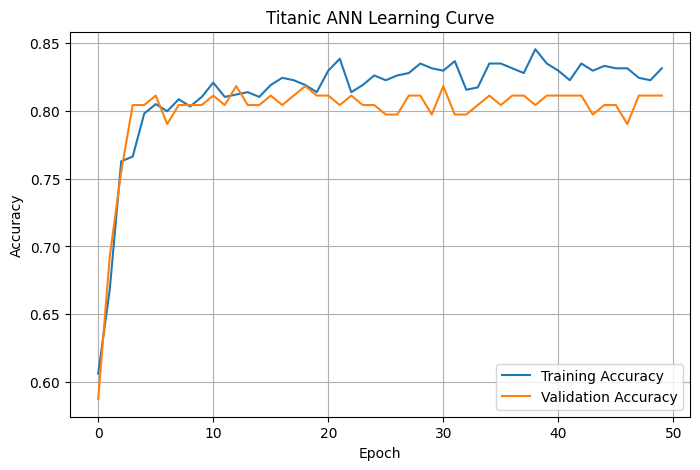


POST-LAB COMPLETED SUCCESSFULLY
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 08 - POST LAB
# Artificial Neural Network on Titanic Dataset
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("=" * 60)
print("EXPERIMENT 08 - POST LAB")
print("ANN on Titanic Dataset")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load Titanic Dataset
# ------------------------------------------------------------

url = (
    "https://raw.githubusercontent.com/"
    "datasciencedojo/datasets/master/titanic.csv"
)

df = pd.read_csv(
    url
)

print("\nDataset Shape:")
print(
    df.shape
)

# ------------------------------------------------------------
# 2. Select Features
# ------------------------------------------------------------

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

X = df[features].copy()

y = df["Survived"]

# ------------------------------------------------------------
# 3. Encode Sex
# ------------------------------------------------------------

X["Sex"] = X["Sex"].map({
    "male": 0,
    "female": 1
})

# ------------------------------------------------------------
# 4. Handle Missing Values
# ------------------------------------------------------------

X = X.fillna(
    X.median()
)

# ------------------------------------------------------------
# 5. Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# 6. Standardization
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

# ------------------------------------------------------------
# 7. Build ANN
# ------------------------------------------------------------

ann = Sequential([
    Dense(
        32,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

# ------------------------------------------------------------
# 8. Compile
# ------------------------------------------------------------

ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann.summary()

# ------------------------------------------------------------
# 9. Train
# ------------------------------------------------------------

history = ann.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=16,
    verbose=0
)

# ------------------------------------------------------------
# 10. Evaluate
# ------------------------------------------------------------

loss, accuracy = ann.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    f"\nTitanic ANN Test Accuracy: "
    f"{accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# 11. Predictions
# ------------------------------------------------------------

probabilities = ann.predict(
    X_test,
    verbose=0
).ravel()

predictions = (
    probabilities >= 0.5
).astype(int)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        predictions
    )
)

# ------------------------------------------------------------
# 12. Learning Curve
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Titanic ANN Learning Curve"
)

plt.legend()
plt.grid(True)

plt.show()

print("\n" + "=" * 60)
print("POST-LAB COMPLETED SUCCESSFULLY")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)